In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.gridspec as gridspec

In [31]:
!pip install plotly kaleido

  Using cached pytest_timeout-2.4.0-py3-none-any.whl.metadata (20 kB)
  Using cached simplejson-3.20.2-cp312-cp312-macosx_11_0_arm64.whl.metadata (3.4 kB)
  Using cached iniconfig-2.3.0-py3-none-any.whl.metadata (2.5 kB)
  Using cached pluggy-1.6.0-py3-none-any.whl.metadata (4.8 kB)
Using cached pytest_timeout-2.4.0-py3-none-any.whl (14 kB)
Using cached simplejson-3.20.2-cp312-cp312-macosx_11_0_arm64.whl (75 kB)
Using cached iniconfig-2.3.0-py3-none-any.whl (7.5 kB)
Using cached pluggy-1.6.0-py3-none-any.whl (20 kB)

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
data_path = "/Users/rhalder/PycharmProjects/EC_Prediction/artifacts/feature_analysis.json"
output_dir = "/Users/rhalder/PycharmProjects/EC_Prediction/plots"
os.makedirs(output_dir, exist_ok=True)

In [3]:
# ── Config ──
COLORS = {
    "motif": "#2ecc71",
    "amino_acid": "#e74c3c",
    "distributed": "#f39c12",
    "bg": "#0a0e14",
    "text": "#c0c0c0",
    "grid": "#1a1e28",
    "accent": "#58a6ff"
}

AA_COLORS = {
    "G": "#7ec8e3", "A": "#7ec8e3", "V": "#5b9bd5", "L": "#5b9bd5", "I": "#5b9bd5", "P": "#4a86c8",
    "F": "#c084d8", "W": "#a855c0", "Y": "#d4a0e0", "M": "#e0c878",
    "S": "#68c468", "T": "#68c468", "C": "#d4d84a", "N": "#8ed88e", "Q": "#8ed88e",
    "D": "#e07070", "E": "#e07070", "K": "#7090e0", "R": "#7090e0", "H": "#90a8e8"
}

AA_GROUPS = {
    "Hydrophobic": (["G", "A", "V", "L", "I", "P"], "#5b9bd5"),
    "Aromatic": (["F", "W", "Y"], "#c084d8"),
    "Polar": (["S", "T", "C", "N", "Q", "M"], "#68c468"),
    "Negative": (["D", "E"], "#e07070"),
    "Positive": (["K", "R", "H"], "#7090e0"),
}


def set_dark_style():
    plt.rcParams.update({
        "figure.facecolor": COLORS["bg"],
        "axes.facecolor": COLORS["bg"],
        "axes.edgecolor": COLORS["grid"],
        "axes.labelcolor": COLORS["text"],
        "text.color": COLORS["text"],
        "xtick.color": COLORS["text"],
        "ytick.color": COLORS["text"],
        "grid.color": COLORS["grid"],
        "font.family": "monospace",
        "font.size": 10,
    })

In [4]:
def load_data(path):
    with open(path) as f:
        return json.load(f)

In [48]:
# ══════════════════════════════════════════════════════════════
# Activation Heatmap for One Protein
# ══════════════════════════════════════════════════════════════
def plot_activation_heatmap(protein_data, save_path=None):
    set_dark_style()
    ec = protein_data["ec"][0] if isinstance(protein_data["ec"], list) else protein_data["ec"]
    length = protein_data["length"]
    features = protein_data["features"]

    if len(features) == 0:
        print("No features to plot")
        return None

    fig, axes = plt.subplots(len(features), 1, figsize=(14, 2.2 * len(features)),
                              sharex=True, gridspec_kw={"hspace": 0.4})
    if len(features) == 1:
        axes = [axes]

    fig.suptitle(f"SAE Feature Activations — {ec} ({length} residues)",
                 fontsize=14, fontweight="bold", y=1.01)

    for idx, (ax, feat) in enumerate(zip(axes, features)):
        # Create activation vector
        act_vector = np.zeros(length)
        for r in feat["residues"]:
            if r["pos"] < length:
                act_vector[r["pos"]] = r["act"]

        # Color based on type
        type_color = COLORS.get(feat["type"], "#888888")

        # Plot as bar
        positions = np.arange(length)
        ax.bar(positions, act_vector, width=1.0, color=type_color, alpha=0.7)

        # Mark top residues with AA labels
        for r in feat["residues"][:5]:
            if r["pos"] < length and r["act"] > 0:
                ax.annotate(f"{r['aa']}{r['pos']}", xy=(r["pos"], r["act"]),
                           fontsize=6, ha="center", va="bottom", color="#ffffff",
                           fontweight="bold")

        # Feature label
        type_label = {"amino_acid": "AA", "motif": "MOTIF", "distributed": "DIST"}.get(feat["type"], "?")
        ax.set_ylabel(f"#{feat['id']}\n[{type_label}]", fontsize=8, rotation=0, labelpad=50, va="center")
        ax.set_xlim(0, length)
        ax.tick_params(axis="y", labelsize=7)

        # Subtle grid
        ax.grid(axis="x", alpha=0.1)

    axes[-1].set_xlabel("Residue Position", fontsize=10)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")
    # return fig

In [46]:
import json

def print_feature_comparisons(data):
    n = len(data)
    feature_sets = {}
    
    for i, p in enumerate(data):
        ec = p["ec"][0] if isinstance(p["ec"], list) else p["ec"]
        fids = set(f["id"] for f in p["features"])
        feature_sets[i] = {"ec": ec, "features": fids}
    
    for i in range(n):
        for j in range(i + 1, n):
            ec_i = feature_sets[i]["ec"]
            ec_j = feature_sets[j]["ec"]
            fi = feature_sets[i]["features"]
            fj = feature_sets[j]["features"]
            
            shared = fi & fj
            only_i = fi - fj
            only_j = fj - fi
            same_ec = ec_i == ec_j
            
            print(f"\n{'='*60}")
            print(f"P{i} ({ec_i}) vs P{j} ({ec_j})")
            if same_ec:
                print(">>> SAME EC CLASS <<<")
            print(f"{'='*60}")
            print(f"Shared features ({len(shared)}): {sorted(shared)}")
            print(f"Only P{i} ({len(only_i)}): {sorted(only_i)}")
            print(f"Only P{j} ({len(only_j)}): {sorted(only_j)}")
            print(f"Overlap: {len(shared)}/{max(len(fi), len(fj))} = {len(shared)/max(len(fi), len(fj))*100:.0f}%")


# Usage:
# with open("../artifacts/feature_analysis.json") as f:
#     data = json.load(f)

print_feature_comparisons(data)


P0 (['EC:6.1.1.22']) vs P1 (['EC:2.8.1.13'])
Shared features (0): []
Only P0 (10): [476, 508, 1732, 1919, 2262, 2446, 2511, 3140, 4343, 4853]
Only P1 (10): [204, 649, 1015, 1151, 1846, 2182, 2987, 3458, 4043, 4602]
Overlap: 0/10 = 0%

P0 (['EC:6.1.1.22']) vs P2 (['EC:2.3.3.13'])
Shared features (1): [4853]
Only P0 (9): [476, 508, 1732, 1919, 2262, 2446, 2511, 3140, 4343]
Only P2 (9): [204, 400, 645, 743, 1022, 1207, 1798, 3424, 4128]
Overlap: 1/10 = 10%

P0 (['EC:6.1.1.22']) vs P3 (['EC:2.3.3.13'])
Shared features (1): [4853]
Only P0 (9): [476, 508, 1732, 1919, 2262, 2446, 2511, 3140, 4343]
Only P3 (9): [204, 400, 645, 743, 1022, 1207, 1798, 3424, 4128]
Overlap: 1/10 = 10%

P0 (['EC:6.1.1.22']) vs P4 (['EC:2.7.7.60'])
Shared features (0): []
Only P0 (10): [476, 508, 1732, 1919, 2262, 2446, 2511, 3140, 4343, 4853]
Only P4 (10): [193, 204, 521, 866, 1207, 1349, 3203, 3278, 4043, 4890]
Overlap: 0/10 = 0%

P0 (['EC:6.1.1.22']) vs P5 (['EC:2.7.1.33'])
Shared features (4): [2262, 2446, 2511

In [38]:
# ══════════════════════════════════════════════════════════════
# Feature Overlap Heatmap
# ══════════════════════════════════════════════════════════════
def plot_feature_overlap(data, save_path=None):
    set_dark_style()
    n = len(data)
    overlap_matrix = np.zeros((n, n))
    feature_sets = [set(f["id"] for f in p["features"]) for p in data]

    for i in range(n):
        for j in range(n):
            if i == j:
                overlap_matrix[i][j] = len(feature_sets[i])
            else:
                overlap_matrix[i][j] = len(feature_sets[i] & feature_sets[j])

    fig, ax = plt.subplots(figsize=(10, 8))

    # Custom colormap
    cmap = LinearSegmentedColormap.from_list("custom", ["#0a0e14", "#1a3a5c", "#58a6ff", "#ffffff"])
    im = ax.imshow(overlap_matrix, cmap=cmap, aspect="equal")

    # Add text annotations
    for i in range(n):
        for j in range(n):
            val = int(overlap_matrix[i][j])
            if i != j:
                # Highlight same EC
                same_ec = str(data[i]["ec"]) == str(data[j]["ec"])
                color = "#2ecc71" if same_ec else ("#ffffff" if val > 5 else "#666666")
                fontweight = "bold" if same_ec else "normal"
                ax.text(j, i, str(val), ha="center", va="center", fontsize=7,
                        color=color, fontweight=fontweight)

    labels = [f"P{i}" for i in range(n)]
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(labels, fontsize=7, rotation=45)
    ax.set_yticklabels(labels, fontsize=7)
    ax.set_title("Feature Overlap Between Proteins\n(green = same EC class)", fontsize=13, fontweight="bold")

    plt.colorbar(im, ax=ax, label="Shared Features", shrink=0.8)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")
    # return fig


In [39]:
# ══════════════════════════════════════════════════════════════
# Feature Type Distribution (stacked bar per protein)
# ══════════════════════════════════════════════════════════════
# def plot_feature_type_distribution(data, save_path=None):
#     set_dark_style()
#     fig, ax = plt.subplots(figsize=(12, 5))

#     proteins = []
#     for i, p in enumerate(data):
#         ec = p["ec"][0] if isinstance(p["ec"], list) else p["ec"]
#         motifs = sum(1 for f in p["features"] if f["type"] == "motif")
#         aa = sum(1 for f in p["features"] if f["type"] == "amino_acid")
#         dist = sum(1 for f in p["features"] if f["type"] == "distributed")
#         proteins.append({"idx": i, "ec": ec, "motif": motifs, "aa": aa, "dist": dist})

#     x = np.arange(len(proteins))
#     width = 0.6

#     motifs = [p["motif"] for p in proteins]
#     aas = [p["aa"] for p in proteins]
#     dists = [p["dist"] for p in proteins]

#     ax.bar(x, dists, width, label="Distributed", color=COLORS["distributed"], alpha=0.85)
#     ax.bar(x, aas, width, bottom=dists, label="AA Detector", color=COLORS["amino_acid"], alpha=0.85)
#     ax.bar(x, motifs, width, bottom=[a + d for a, d in zip(aas, dists)], label="Motif", color=COLORS["motif"], alpha=0.85)

#     ax.set_xlabel("Protein Index")
#     ax.set_ylabel("Number of Features")
#     ax.set_title("SAE Feature Type Distribution Across Proteins", fontsize=13, fontweight="bold")
#     ax.set_xticks(x)
#     ax.set_xticklabels([f"P{p['idx']}" for p in proteins], fontsize=8, rotation=45)
#     ax.legend(loc="upper right", framealpha=0.8)
#     ax.set_ylim(0, max([m + a + d for m, a, d in zip(motifs, aas, dists)]) + 1)

#     # Add EC labels on top
#     for i, p in enumerate(proteins):
#         total = p["motif"] + p["aa"] + p["dist"]
#         ec_short = p["ec"].replace("EC:", "")
#         ax.text(i, total + 0.2, ec_short, ha="center", va="bottom", fontsize=6, color="#888", rotation=45)

#     plt.tight_layout()
#     if save_path:
#         fig.savefig(save_path, dpi=300, bbox_inches="tight")
        # print(f"Saved: {save_path}")
    # return fig

In [40]:
import plotly.graph_objects as go

def plot_feature_type_distribution(data, save_path=None):
    proteins = []
    for i, p in enumerate(data):
        ec = p["ec"][0] if isinstance(p["ec"], list) else p["ec"]
        motifs = sum(1 for f in p["features"] if f["type"] == "motif")
        aa = sum(1 for f in p["features"] if f["type"] == "amino_acid")
        dist = sum(1 for f in p["features"] if f["type"] == "distributed")
        proteins.append({"idx": i, "ec": ec, "motif": motifs, "aa": aa, "dist": dist})

    # labels = [f"P{p['idx']}<br>{p['ec'].replace('EC:', '')}" for p in proteins]
    labels = [f"{p['ec'].replace('EC:', '')}" for p in proteins]
    motifs = [p["motif"] for p in proteins]
    aas = [p["aa"] for p in proteins]
    dists = [p["dist"] for p in proteins]

    fig = go.Figure()

    fig.add_trace(go.Bar(
        name="Distributed", x=labels, y=dists,
        marker_color="#f39c12", opacity=0.85
    ))
    fig.add_trace(go.Bar(
        name="AA Detector", x=labels, y=aas,
        marker_color="#e74c3c", opacity=0.85
    ))
    fig.add_trace(go.Bar(
        name="Motif", x=labels, y=motifs,
        marker_color="#2ecc71", opacity=0.85
    ))

    fig.update_layout(
        barmode="stack",
        title="SAE Feature Type Distribution Across Proteins",
        xaxis_title="Protein",
        yaxis_title="Number of Features",
        template="plotly_dark",
        paper_bgcolor="#0a0e14",
        plot_bgcolor="#0a0e14",
        font=dict(family="monospace", size=11),
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
        height=500, width=900
    )

    if save_path:
        fig.write_html(save_path.replace(".png", ".html"))
        fig.write_image(save_path, scale=3)
        print(f"Saved: {save_path}")

    fig.show()

In [41]:
# ══════════════════════════════════════════════════════════════
# PLOT 4: Dead Features & Active Features Summary
# ══════════════════════════════════════════════════════════════
def plot_dead_features(data, save_path=None):
    set_dark_style()
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Left: Dead feature % per protein
    dead_pcts = [p["dead_features_pct"] for p in data]
    active_counts = [p["active_features"] for p in data]
    x = np.arange(len(data))

    bars = ax1.bar(x, dead_pcts, color="#e74c3c", alpha=0.7, width=0.6)
    ax1.axhline(y=np.mean(dead_pcts), color="#f39c12", linestyle="--", linewidth=1, alpha=0.7,
                label=f"Mean: {np.mean(dead_pcts):.1f}%")
    ax1.set_xlabel("Protein Index")
    ax1.set_ylabel("Dead Features (%)")
    ax1.set_title("Dead Features per Protein", fontsize=12, fontweight="bold")
    ax1.set_xticks(x)
    ax1.set_xticklabels([f"P{i}" for i in range(len(data))], fontsize=7, rotation=45)
    ax1.set_ylim(80, 90)
    ax1.legend(fontsize=9)

    # Right: Active features vs protein length
    lengths = [p["length"] for p in data]
    ax2.scatter(lengths, active_counts, c=COLORS["accent"], s=50, alpha=0.8, edgecolors="#ffffff", linewidths=0.5)
    ax2.set_xlabel("Protein Length (residues)")
    ax2.set_ylabel("Active Features (out of 5120)")
    ax2.set_title("Active Features vs Protein Length", fontsize=12, fontweight="bold")

    # Add trend line
    z = np.polyfit(lengths, active_counts, 1)
    p_line = np.poly1d(z)
    x_line = np.linspace(min(lengths), max(lengths), 100)
    ax2.plot(x_line, p_line(x_line), color="#f39c12", linestyle="--", alpha=0.7)

    # Annotate correlation
    corr = np.corrcoef(lengths, active_counts)[0, 1]
    ax2.text(0.05, 0.95, f"r = {corr:.3f}", transform=ax2.transAxes,
             fontsize=10, va="top", color="#f39c12")

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")
    return fig

In [42]:
# ══════════════════════════════════════════════════════════════
# PLOT 5: Amino Acid Composition of Features
# ══════════════════════════════════════════════════════════════
def plot_aa_composition(data, save_path=None):
    set_dark_style()
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Collect AA frequencies for motif vs AA detector features
    motif_aas = {}
    aa_det_aas = {}

    for p in data:
        for f in p["features"]:
            target = motif_aas if f["type"] == "motif" else aa_det_aas if f["type"] == "amino_acid" else None
            if target is not None:
                for r in f["residues"]:
                    aa = r["aa"]
                    target[aa] = target.get(aa, 0) + 1

    # Sort by standard AA order
    all_aas = sorted(set(list(motif_aas.keys()) + list(aa_det_aas.keys())))

    # Left: Motif features AA distribution
    motif_counts = [motif_aas.get(aa, 0) for aa in all_aas]
    motif_colors = [AA_COLORS.get(aa, "#888") for aa in all_aas]
    ax1.barh(all_aas, motif_counts, color=motif_colors, alpha=0.8)
    ax1.set_xlabel("Count")
    ax1.set_title("Motif Features — Residue Diversity", fontsize=12, fontweight="bold", color=COLORS["motif"])
    ax1.invert_yaxis()

    # Right: AA detector features AA distribution
    aa_det_counts = [aa_det_aas.get(aa, 0) for aa in all_aas]
    aa_det_colors = [AA_COLORS.get(aa, "#888") for aa in all_aas]
    ax2.barh(all_aas, aa_det_counts, color=aa_det_colors, alpha=0.8)
    ax2.set_xlabel("Count")
    ax2.set_title("AA Detector Features — Residue Types", fontsize=12, fontweight="bold", color=COLORS["amino_acid"])
    ax2.invert_yaxis()

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")
    return fig


In [58]:
count = 0

for i, p in enumerate(data):
    motifs = sum(1 for f in p["features"] if f["type"] == "motif")
    aa = sum(1 for f in p["features"] if f["type"] == "amino_acid")
    dist = sum(1 for f in p["features"] if f["type"] == "distributed")
    #print(f'Data Count = {count+1}, Motifs = {motifs}, AA = {aa}, Dist = {dist}')
    print(f'{p['ec']}')
    count += 1

['EC:6.1.1.22']
['EC:2.8.1.13']
['EC:2.3.3.13']
['EC:2.3.3.13']
['EC:2.7.7.60']
['EC:2.7.1.33']
['EC:2.7.10.2']
['EC:2.1.1.35']
['EC:4.2.1.109']
['EC:4.2.1.11']
['EC:4.2.1.11']
['EC:6.3.1.13']
['EC:2.7.1.167', 'EC:2.7.7.70']
['EC:4.6.1.12']
['EC:3.1.1.4']
['EC:1.3.7.11']
['EC:4.2.1.33']
['EC:6.1.1.21']
['EC:2.3.2.23']
['EC:6.1.1.20']


In [44]:
data = load_data(data_path)
print(f"Loaded {len(data)} proteins")

# Generate all plots
print("\n1. Feature type distribution...")
plot_feature_type_distribution(data, f"{output_dir}/plot1_feature_types.png")

Loaded 20 proteins

1. Feature type distribution...
Saved: /Users/rhalder/PycharmProjects/EC_Prediction/plots/plot1_feature_types.png


2. Feature overlap heatmap...
Saved: /Users/rhalder/PycharmProjects/EC_Prediction/plots/plot2_overlap.png


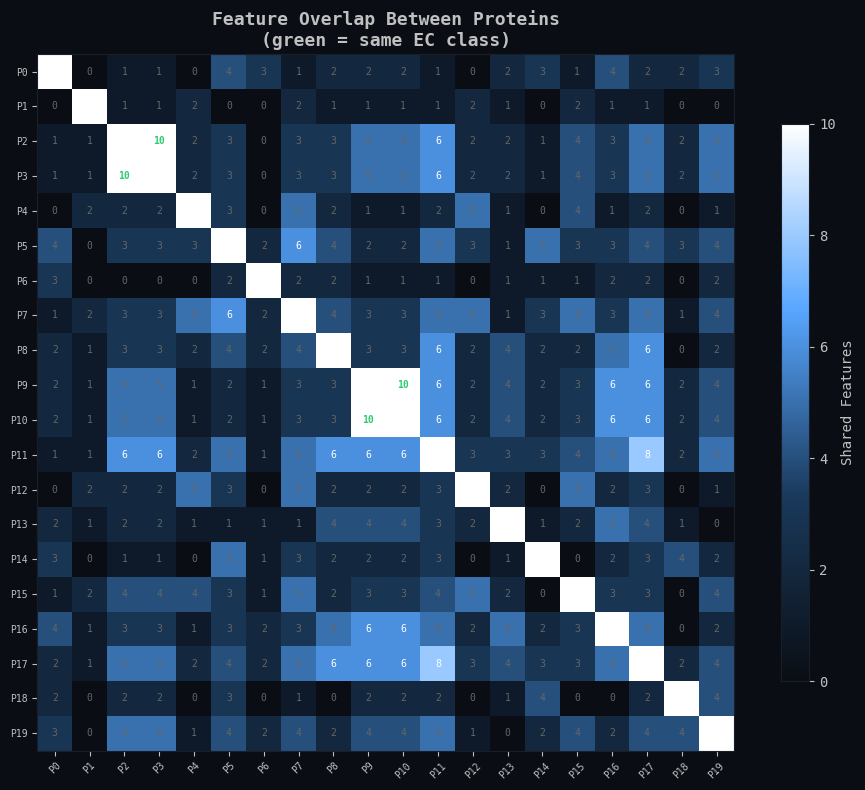

In [45]:
print("2. Feature overlap heatmap...")
plot_feature_overlap(data, f"{output_dir}/plot2_overlap.png")

In [12]:
data

[{'ec': "['EC:6.1.1.22']",
  'length': 466,
  'active_features': 650,
  'dead_features_pct': 87.3,
  'features': [{'id': 4853,
    'label': 'Distributed pattern',
    'type': 'distributed',
    'total_activation': 726.12,
    'residues': [{'pos': 220, 'aa': 'C', 'act': 4.08},
     {'pos': 313, 'aa': 'C', 'act': 3.669},
     {'pos': 280, 'aa': 'C', 'act': 3.37},
     {'pos': 71, 'aa': 'C', 'act': 3.32},
     {'pos': 260, 'aa': 'D', 'act': 3.227},
     {'pos': 148, 'aa': 'H', 'act': 3.149},
     {'pos': 322, 'aa': 'C', 'act': 3.127},
     {'pos': 45, 'aa': 'C', 'act': 3.074}]},
   {'id': 508,
    'label': 'K detector',
    'type': 'amino_acid',
    'total_activation': 536.96,
    'residues': [{'pos': 1, 'aa': 'K', 'act': 11.24},
     {'pos': 28, 'aa': 'K', 'act': 11.218},
     {'pos': 74, 'aa': 'K', 'act': 11.096},
     {'pos': 192, 'aa': 'K', 'act': 10.971},
     {'pos': 61, 'aa': 'K', 'act': 10.969},
     {'pos': 424, 'aa': 'K', 'act': 10.803},
     {'pos': 97, 'aa': 'K', 'act': 10.628

3. Activation heatmaps (per protein)...


/var/folders/_4/mt2jwyyd3ls_p621k2sz8vhr0000gn/T/ipykernel_50352/286205816.py:53: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



Saved: /Users/rhalder/PycharmProjects/EC_Prediction/plots/plot3_activations_P1.png
Saved: /Users/rhalder/PycharmProjects/EC_Prediction/plots/plot3_activations_P0.png


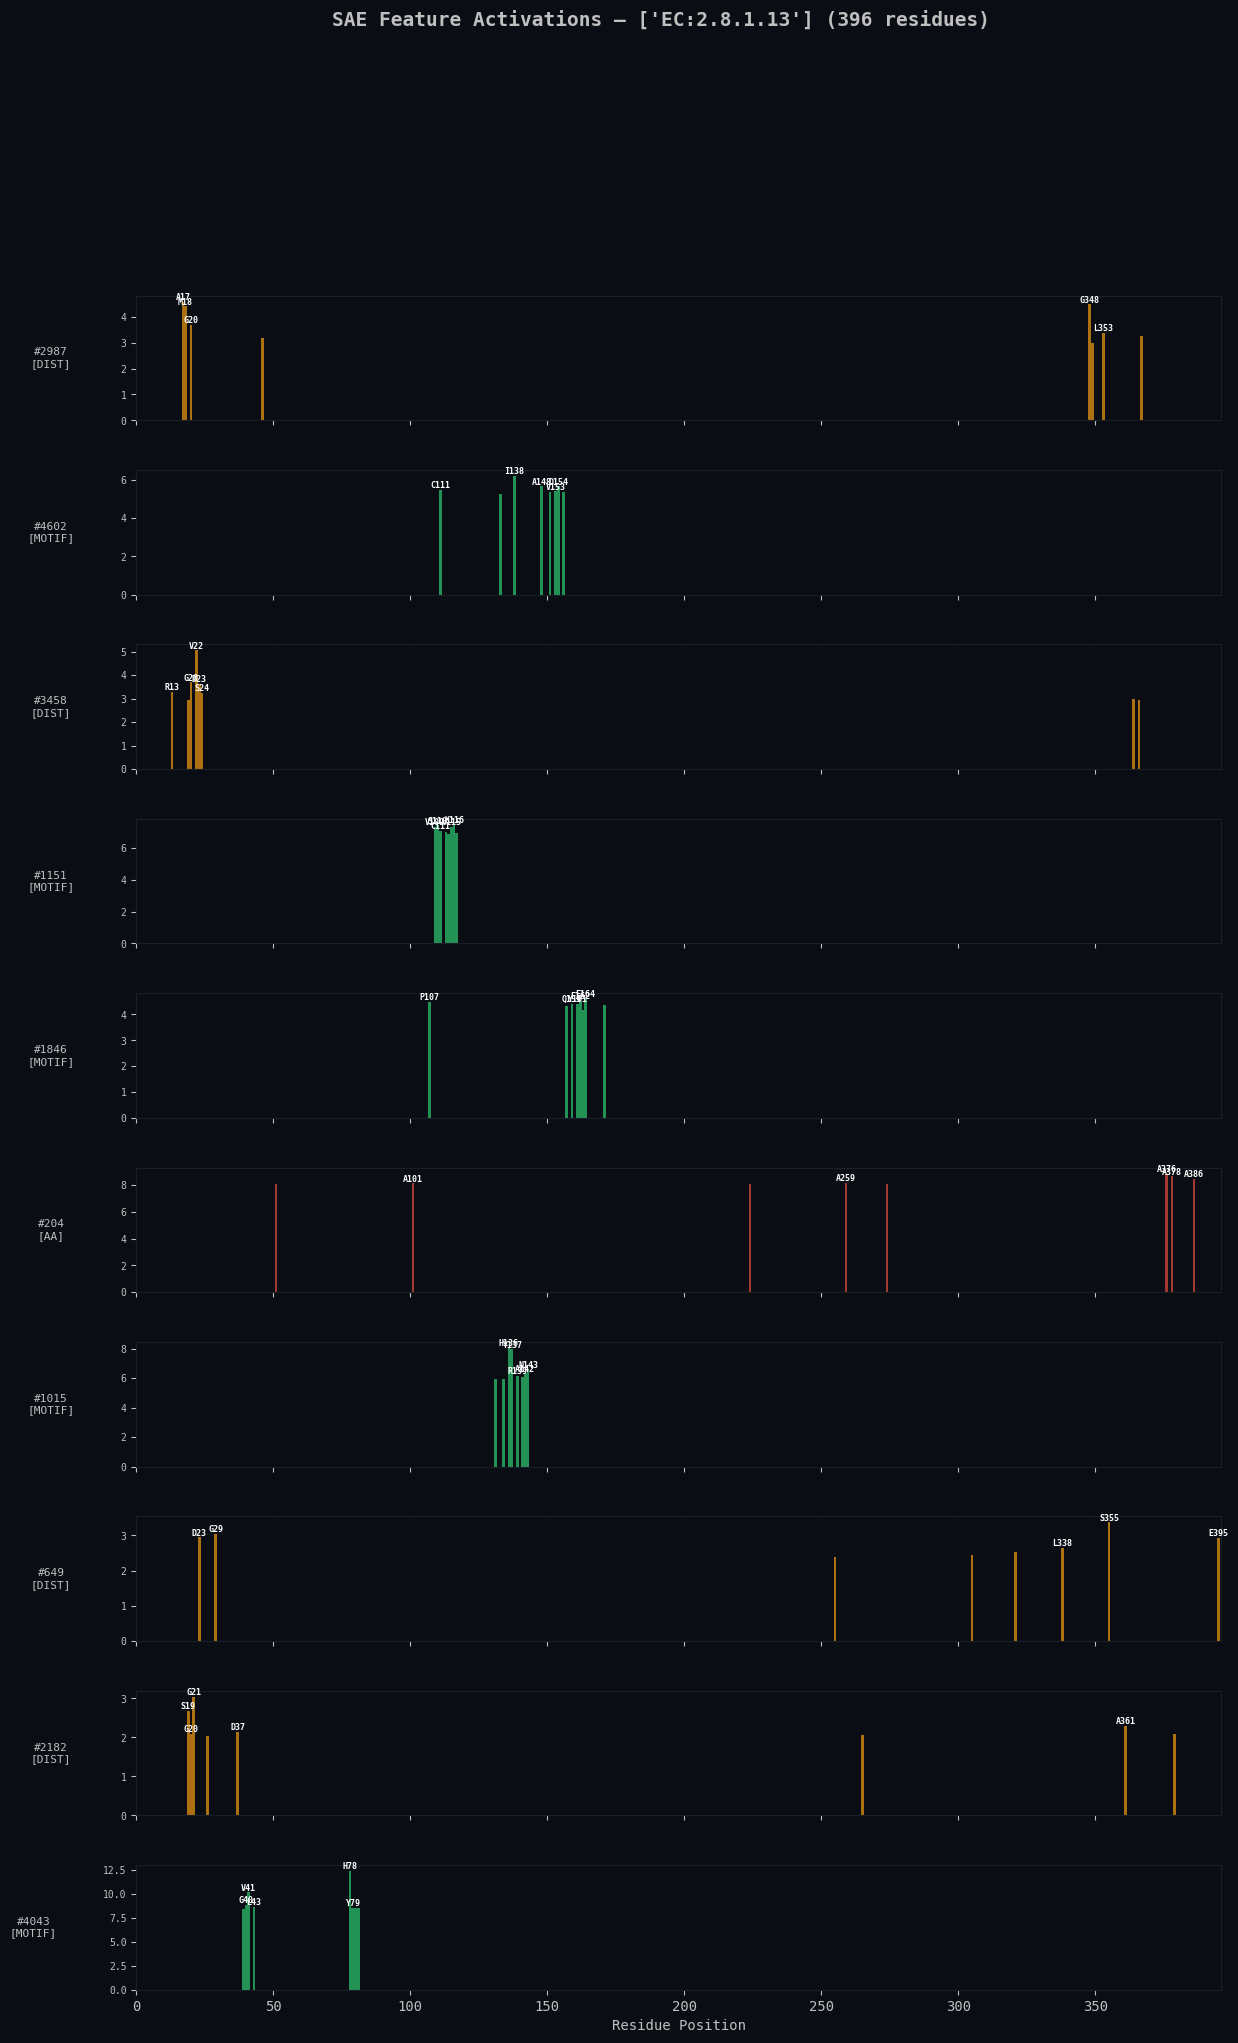

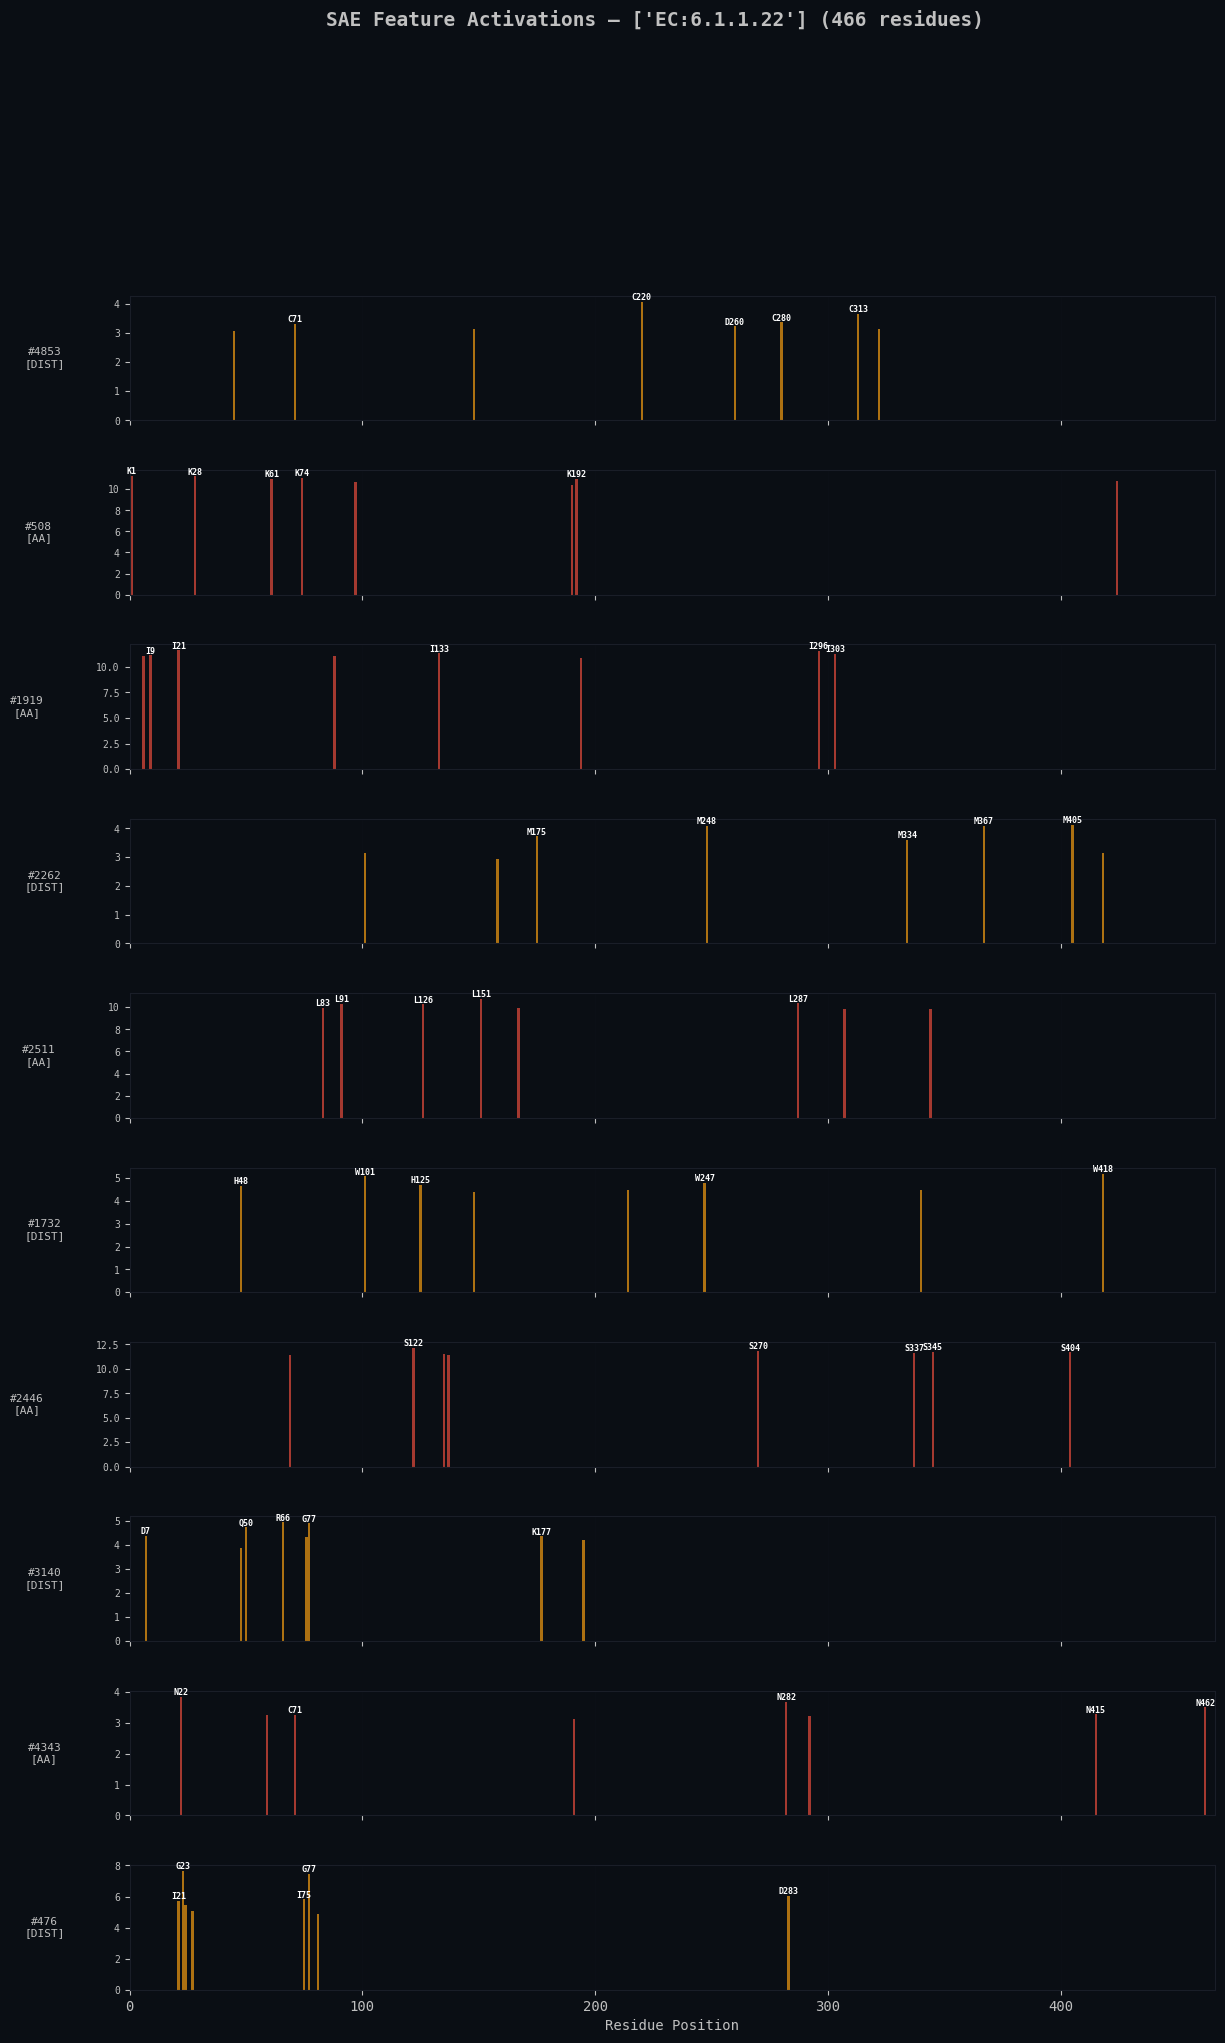

In [49]:
print("3. Activation heatmaps (per protein)...")
# Best motif protein
best_idx = max(range(len(data)),
               key=lambda i: sum(1 for f in data[i]["features"] if f["type"] == "motif"))
plot_activation_heatmap(data[best_idx], f"{output_dir}/plot3_activations_P{best_idx}.png")
# Also plot protein 0 for comparison
plot_activation_heatmap(data[0], f"{output_dir}/plot3_activations_P0.png")

In [61]:
data[0]

{'ec': "['EC:6.1.1.22']",
 'length': 466,
 'active_features': 650,
 'dead_features_pct': 87.3,
 'features': [{'id': 4853,
   'label': 'Distributed pattern',
   'type': 'distributed',
   'total_activation': 726.12,
   'residues': [{'pos': 220, 'aa': 'C', 'act': 4.08},
    {'pos': 313, 'aa': 'C', 'act': 3.669},
    {'pos': 280, 'aa': 'C', 'act': 3.37},
    {'pos': 71, 'aa': 'C', 'act': 3.32},
    {'pos': 260, 'aa': 'D', 'act': 3.227},
    {'pos': 148, 'aa': 'H', 'act': 3.149},
    {'pos': 322, 'aa': 'C', 'act': 3.127},
    {'pos': 45, 'aa': 'C', 'act': 3.074}]},
  {'id': 508,
   'label': 'K detector',
   'type': 'amino_acid',
   'total_activation': 536.96,
   'residues': [{'pos': 1, 'aa': 'K', 'act': 11.24},
    {'pos': 28, 'aa': 'K', 'act': 11.218},
    {'pos': 74, 'aa': 'K', 'act': 11.096},
    {'pos': 192, 'aa': 'K', 'act': 10.971},
    {'pos': 61, 'aa': 'K', 'act': 10.969},
    {'pos': 424, 'aa': 'K', 'act': 10.803},
    {'pos': 97, 'aa': 'K', 'act': 10.628},
    {'pos': 190, 'aa': '

4. Dead features analysis...
Saved: /Users/rhalder/PycharmProjects/EC_Prediction/plots/plot4_dead_features.png


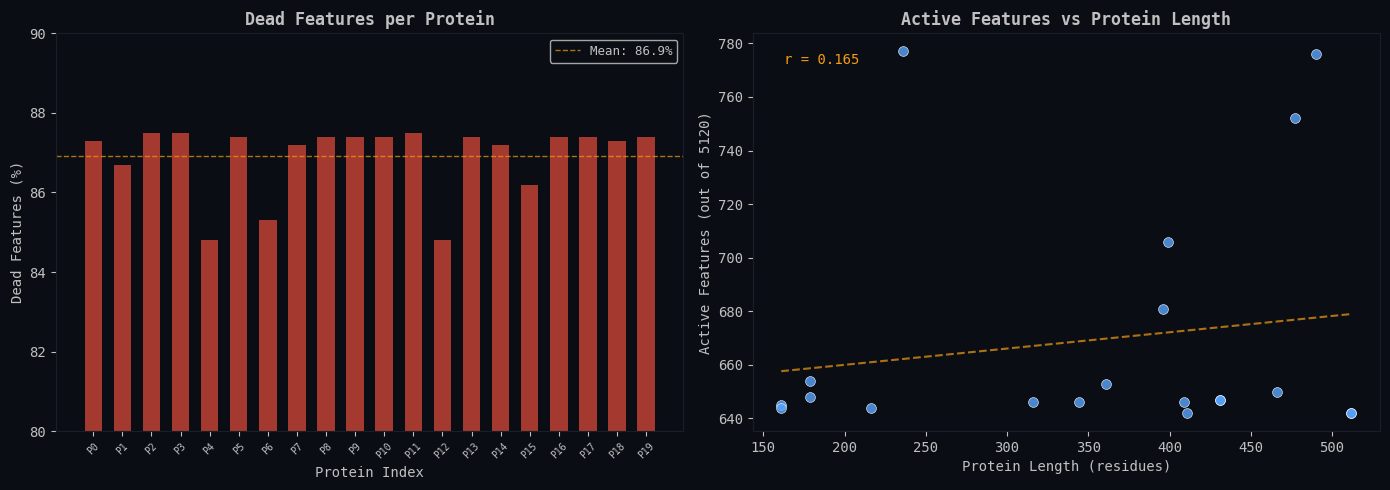

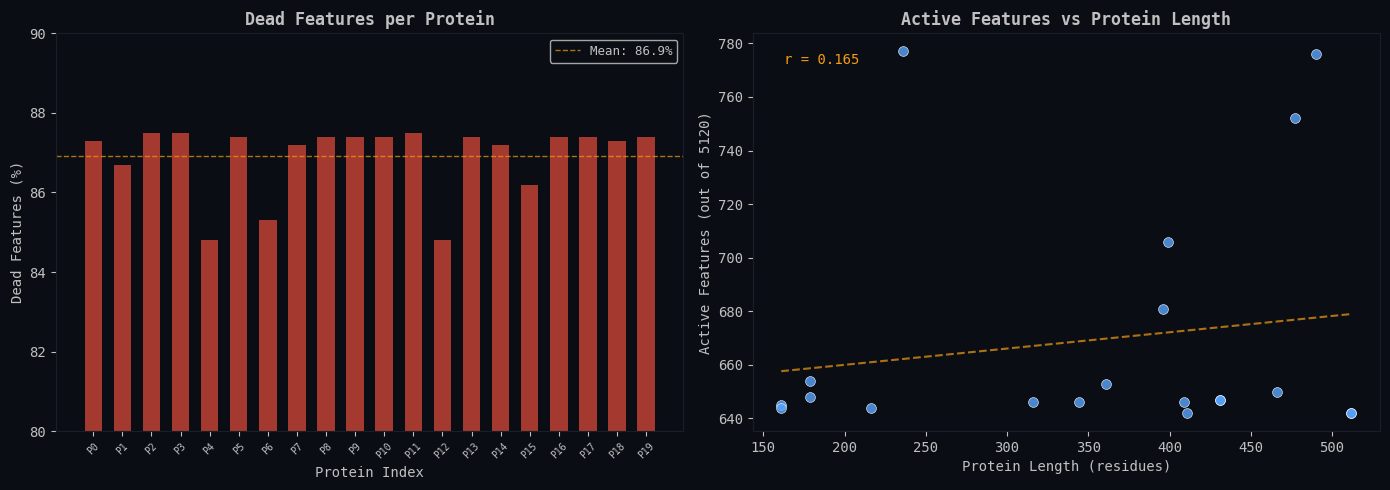

In [50]:
print("4. Dead features analysis...")
plot_dead_features(data, f"{output_dir}/plot4_dead_features.png")

5. AA composition...
Saved: /Users/rhalder/PycharmProjects/EC_Prediction/plots/plot5_aa_composition.png


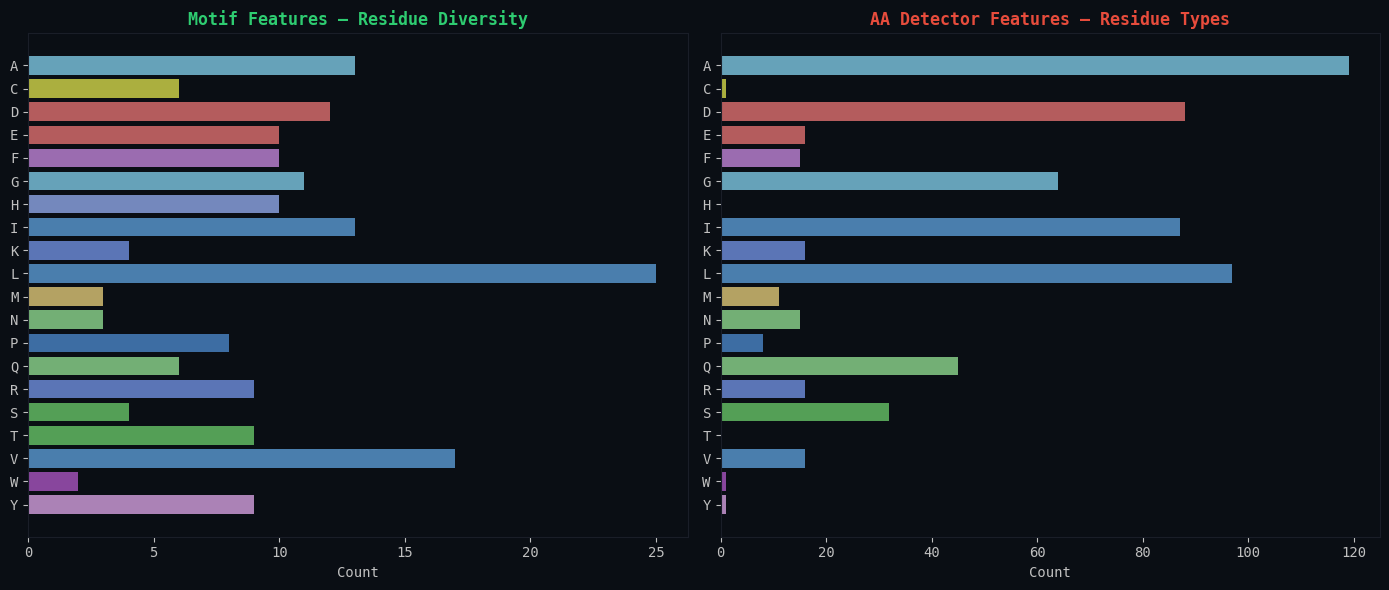

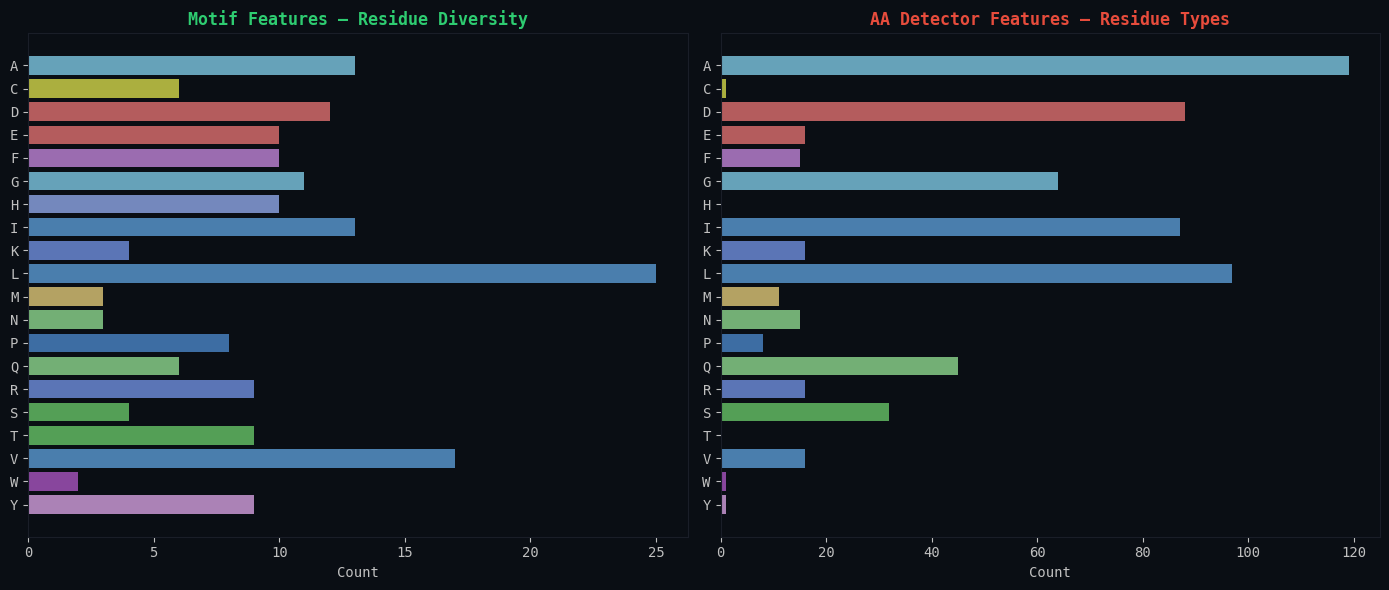

In [51]:
print("5. AA composition...")
plot_aa_composition(data, f"{output_dir}/plot5_aa_composition.png")